In [60]:
import pandas as pd
import cv2
import numpy as np

In [61]:
'''
This code is because the metadata that the labeling script generates is bad so we are going to redo it for the labeled data 
'''

'\nThis code is because the metadata that the labeling script generates is bad so we are going to redo it for the labeled data \n'

In [62]:
labels = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/submission/v1/labels.csv')
pole_metadata = pd.read_csv('/Users/cmbreen/Documents/snow/alaska_dataset/submission/v1/pole_metadata.csv')

In [63]:
labels['year'][0]

'2022-2023'

In [64]:
### for 2022-2023 reproject to native res 
image = cv2.imread('/Users/cmbreen/Documents/snow/alaska_dataset/labeled_images_part2/CP_BA_2_WSCT1749.JPG')
h, w, _ = image.shape  # Fixed: cv2 returns (height, width, channels)
print(f"Height: {h}, Width: {w}")

# Create a mask for 2022-2023 rows
mask_2022_2023 = labels['year'] == '2022-2023'

# Update coordinates directly in the dataframe for 2022-2023 rows
labels.loc[mask_2022_2023, 'top_x'] = labels.loc[mask_2022_2023, 'top_x'] * w / 448
labels.loc[mask_2022_2023, 'top_y'] = labels.loc[mask_2022_2023, 'top_y'] * h / 448
labels.loc[mask_2022_2023, 'bottom_x'] = labels.loc[mask_2022_2023, 'bottom_x'] * w / 448
labels.loc[mask_2022_2023, 'bottom_y'] = labels.loc[mask_2022_2023, 'bottom_y'] * h / 448

# Verify the changes
print("Updated coordinates for 2022-2023:")
print(labels[labels['year'] == '2022-2023'][['camera_name', 'filename', 'top_x', 'top_y', 'bottom_x', 'bottom_y']].head())

Height: 3420, Width: 6080
Updated coordinates for 2022-2023:
  camera_name               filename        top_x       top_y     bottom_x  \
0    BC11TLSB  BC11TLSB_WSCT1713.JPG  2862.658442  757.910308  2823.177922   
1    BC11TLSB  BC11TLSB_WSCT1724.JPG  2823.177922  760.131088  2854.762338   
2    BC11TLSB  BC11TLSB_WSCT1734.JPG  2846.866234  766.793425  2831.074026   
3    BC11TLSB  BC11TLSB_WSCT1744.JPG  2862.658442  757.910308  2858.710390   
4    BC11TLSB  BC11TLSB_WSCT1754.JPG  2850.814286  757.910308  2831.074026   

      bottom_y  
0  2365.754464  
1  2361.312906  
2  2365.754464  
3  2352.429789  
4  2363.533685  


In [65]:
# Update length_px only for 2022-2023 rows
mask_2022_2023 = labels['year'] == '2022-2023'
labels.loc[mask_2022_2023, 'length_px'] = np.sqrt(
    (labels.loc[mask_2022_2023, 'bottom_x'] - labels.loc[mask_2022_2023, 'top_x'])**2 + 
    (labels.loc[mask_2022_2023, 'bottom_y'] - labels.loc[mask_2022_2023, 'top_y'])**2
)

In [66]:
labels

,camera_name,filename,year,datetime,top_x,top_y,bottom_x,bottom_y,length_px,snow_depth_cm,storm_flag,veg_flag,pole_tilt_flag
0,BC11TLSB,BC11TLSB_WSCT1713.JPG,2022-2023,8/20/23 14:00,2862.658442,757.910308,2823.177922,2365.754464,1608.328804,0.506899,0,0,0
1,BC11TLSB,BC11TLSB_WSCT1724.JPG,2022-2023,8/23/23 16:00,2823.177922,760.131088,2854.762338,2361.312906,1601.493300,1.025626,0,0,0
2,BC11TLSB,BC11TLSB_WSCT1734.JPG,2022-2023,8/27/23 14:00,2846.866234,766.793425,2831.074026,2365.754464,1599.039023,1.202831,0,0,0
3,BC11TLSB,BC11TLSB_WSCT1744.JPG,2022-2023,8/30/23 15:00,2862.658442,757.910308,2858.710390,2352.429789,1594.524368,1.547614,0,0,0
4,BC11TLSB,BC11TLSB_WSCT1754.JPG,2022-2023,9/2/23 16:00,2850.814286,757.910308,2831.074026,2363.533685,1605.744720,0.687275,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CP_WB_3,CP_WB_3_WSCT0211.JPG,2023-2024,11/8/23 16:00,2759.834528,1396.238351,2703.084229,3039.727001,1644.468163,11.521027,0,0,0
1574,CP_WB_3,CP_WB_3_WSCT0221.JPG,2023-2024,11/11/23 17:00,2705.354241,1384.888292,2644.063919,3030.646953,1646.899535,11.342538,0,0,0
1575,CP_WB_3,CP_WB_3_WSCT0231.JPG,2023-2024,11/15/23 15:00,2718.974313,1398.508363,2659.954002,2923.956392,1526.589364,20.174611,0,0,0
1576,CP_WB_3,CP_WB_3_WSCT0241.JPG,2023-2024,11/18/23 16:00,2644.063919,1412.128435,2587.313620,2894.446237,1483.403742,23.344904,0,0,0


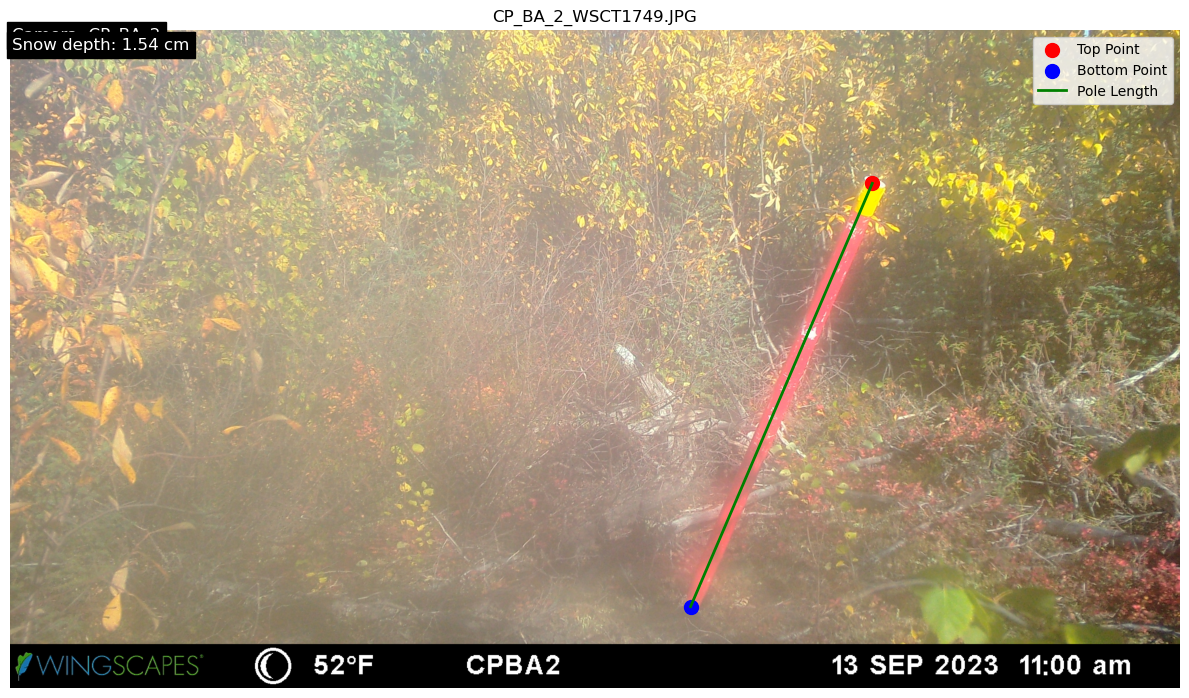

Found 1 entry(ies) for CP_BA_2_WSCT1749.JPG


In [67]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# Load the image
image_path = '/Users/cmbreen/Documents/snow/alaska_dataset/labeled_images_part2/CP_BA_2_WSCT1749.JPG'
image = cv2.imread(image_path)

# Convert from BGR (OpenCV default) to RGB for proper display in matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape

# Find the corresponding row in the dataframe
target_filename = 'CP_BA_2_WSCT1749.JPG'
matching_rows = labels[labels['filename'] == target_filename]

# Create figure
plt.figure(figsize=(12, 8))

# Display the image
plt.imshow(image_rgb)
plt.title(f'{target_filename}')

# If we found the image in the dataframe, plot the keypoints
if not matching_rows.empty:
    for idx, row in matching_rows.iterrows():
        # Extract coordinates (already scaled to native resolution)
        top_x = row['top_x']
        top_y = row['top_y']
        bottom_x = row['bottom_x']
        bottom_y = row['bottom_y']
        
        # Plot keypoints
        plt.scatter(top_x, top_y, c='red', s=100, marker='o', label='Top Point')
        plt.scatter(bottom_x, bottom_y, c='blue', s=100, marker='o', label='Bottom Point')
        
        # Draw a line connecting the points
        plt.plot([top_x, bottom_x], [top_y, bottom_y], 'g-', linewidth=2, label='Pole Length')
        
        # Add camera name text
        plt.text(10, 50, f"Camera: {row['camera_name']}", color='white', 
                 fontsize=12, backgroundcolor='black')
        plt.text(10, 100, f"Snow depth: {row['snow_depth_cm']:.2f} cm", color='white', 
                fontsize=12, backgroundcolor='black')
        
        # Only show legend once
        handles, labels2 = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels2, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper right')
else:
    plt.text(10, 50, f"No data found for {target_filename}", color='white', 
             fontsize=12, backgroundcolor='black')

# Hide axes
plt.axis('off')

# Show the plot
plt.tight_layout()
plt.show()

# Print status
if matching_rows.empty:
    print(f"No data found for {target_filename} in the dataframe")
else:
    print(f"Found {len(matching_rows)} entry(ies) for {target_filename}")



In [68]:
pole_metadata.head()

,camera_name,year,first_pole_length_px,full_pole_length_cm,top10_section_px,pixel_cm_conversion,flag
0,BC11TLSB,22-23,2352.09,143.12,164.00,0.0609,NaN
1,BC13TLWA,22-23,2017.01,150.42,136.24,0.0734,NaN
2,BC15TLWB,22-23,1741.17,135.76,130.31,0.0767,vegetation
3,BC1TLDA,22-23,2342.90,147.51,161.37,0.0619,NaN
4,BC2TLDA,22-23,1986.64,150.62,134.01,0.0746,NaN


In [69]:
snow_depths2 = []
for index, row in labels.iterrows():
    camera = row['camera_name']
    metadata = pole_metadata[pole_metadata['camera_name'] == camera]
    ## snowfree_pole = metadata['full_pole_length_cm']
    conv = metadata['pixel_cm_conversion'].tolist()[0]
    snowfree = metadata['first_pole_length_px'].tolist()[0]
    length_px = row['length_px']
    snowdepth2 = (snowfree*conv) - (conv*length_px)
    snow_depths2.append(snowdepth2)

In [70]:
snow_depths2

[45.29505685297393,
 45.71133902545671,
 45.86080448281811,
 46.13574697496453,
 45.452427559467935,
 46.100034228832456,
 44.904431731999736,
 44.10619654284777,
 -1.3359096120695142,
 12.864776009075825,
 9.338703297225493,
 8.38112809135842,
 10.701517462764485,
 14.218117364904344,
 10.972007925879268,
 11.377086016124082,
 14.08197674481238,
 14.349774684082831,
 13.676243180158679,
 14.347756403814998,
 18.13653880072887,
 22.873586318591606,
 27.607167397576617,
 38.4171265006797,
 34.9082705737716,
 40.986540669511996,
 38.29070662277667,
 38.01142841491702,
 36.66859159871457,
 37.344817141211834,
 37.07024317004202,
 35.71246713020173,
 39.62640775425797,
 37.87921330011133,
 35.992366036067935,
 35.72187580498637,
 36.66208253855662,
 45.862882248766525,
 49.108681040568385,
 52.70909864410898,
 58.306774273066964,
 56.54861097291155,
 143.24228100000002,
 70.27137301574759,
 54.38471617856912,
 59.63258278154059,
 62.227042620780665,
 75.88832802199754,
 68.84329329036441,


In [71]:
labels

,camera_name,filename,year,datetime,top_x,top_y,bottom_x,bottom_y,length_px,snow_depth_cm,storm_flag,veg_flag,pole_tilt_flag
0,BC11TLSB,BC11TLSB_WSCT1713.JPG,2022-2023,8/20/23 14:00,2862.658442,757.910308,2823.177922,2365.754464,1608.328804,0.506899,0,0,0
1,BC11TLSB,BC11TLSB_WSCT1724.JPG,2022-2023,8/23/23 16:00,2823.177922,760.131088,2854.762338,2361.312906,1601.493300,1.025626,0,0,0
2,BC11TLSB,BC11TLSB_WSCT1734.JPG,2022-2023,8/27/23 14:00,2846.866234,766.793425,2831.074026,2365.754464,1599.039023,1.202831,0,0,0
3,BC11TLSB,BC11TLSB_WSCT1744.JPG,2022-2023,8/30/23 15:00,2862.658442,757.910308,2858.710390,2352.429789,1594.524368,1.547614,0,0,0
4,BC11TLSB,BC11TLSB_WSCT1754.JPG,2022-2023,9/2/23 16:00,2850.814286,757.910308,2831.074026,2363.533685,1605.744720,0.687275,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CP_WB_3,CP_WB_3_WSCT0211.JPG,2023-2024,11/8/23 16:00,2759.834528,1396.238351,2703.084229,3039.727001,1644.468163,11.521027,0,0,0
1574,CP_WB_3,CP_WB_3_WSCT0221.JPG,2023-2024,11/11/23 17:00,2705.354241,1384.888292,2644.063919,3030.646953,1646.899535,11.342538,0,0,0
1575,CP_WB_3,CP_WB_3_WSCT0231.JPG,2023-2024,11/15/23 15:00,2718.974313,1398.508363,2659.954002,2923.956392,1526.589364,20.174611,0,0,0
1576,CP_WB_3,CP_WB_3_WSCT0241.JPG,2023-2024,11/18/23 16:00,2644.063919,1412.128435,2587.313620,2894.446237,1483.403742,23.344904,0,0,0


In [ ]:
labels['snow_depth_cm2'] =snow_depths2

In [73]:
labels

,camera_name,filename,year,datetime,top_x,top_y,bottom_x,bottom_y,length_px,snow_depth_cm,storm_flag,veg_flag,pole_tilt_flag,snow_depth_cm2
0,BC11TLSB,BC11TLSB_WSCT1713.JPG,2022-2023,8/20/23 14:00,2862.658442,757.910308,2823.177922,2365.754464,1608.328804,0.506899,0,0,0,45.295057
1,BC11TLSB,BC11TLSB_WSCT1724.JPG,2022-2023,8/23/23 16:00,2823.177922,760.131088,2854.762338,2361.312906,1601.493300,1.025626,0,0,0,45.711339
2,BC11TLSB,BC11TLSB_WSCT1734.JPG,2022-2023,8/27/23 14:00,2846.866234,766.793425,2831.074026,2365.754464,1599.039023,1.202831,0,0,0,45.860804
3,BC11TLSB,BC11TLSB_WSCT1744.JPG,2022-2023,8/30/23 15:00,2862.658442,757.910308,2858.710390,2352.429789,1594.524368,1.547614,0,0,0,46.135747
4,BC11TLSB,BC11TLSB_WSCT1754.JPG,2022-2023,9/2/23 16:00,2850.814286,757.910308,2831.074026,2363.533685,1605.744720,0.687275,0,0,0,45.452428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CP_WB_3,CP_WB_3_WSCT0211.JPG,2023-2024,11/8/23 16:00,2759.834528,1396.238351,2703.084229,3039.727001,1644.468163,11.521027,0,0,0,11.265394
1574,CP_WB_3,CP_WB_3_WSCT0221.JPG,2023-2024,11/11/23 17:00,2705.354241,1384.888292,2644.063919,3030.646953,1646.899535,11.342538,0,0,0,11.061159
1575,CP_WB_3,CP_WB_3_WSCT0231.JPG,2023-2024,11/15/23 15:00,2718.974313,1398.508363,2659.954002,2923.956392,1526.589364,20.174611,0,0,0,21.167213
1576,CP_WB_3,CP_WB_3_WSCT0241.JPG,2023-2024,11/18/23 16:00,2644.063919,1412.128435,2587.313620,2894.446237,1483.403742,23.344904,0,0,0,24.794806


Found 24 cameras: ['BC11TLSB' 'BC13TLWA' 'BC15TLWB' 'BC1TLDA' 'BC2TLDA' 'BC3' 'BC5TLDSB'
 'BC7TLEB' 'BC8TLSA' 'CP BA 2' 'CP DB 15' 'CP DB 6' 'CP EA 4 part fail'
 'CP MA 12 part fail' 'CP SA 5' 'CP_BA_2' 'CP_DB_15' 'CP_DB_6' 'CP_EA_4'
 'CP_EB_13' 'CP_MA_12' 'CP_MB_14' 'CP_SA_5' 'CP_WB_3']


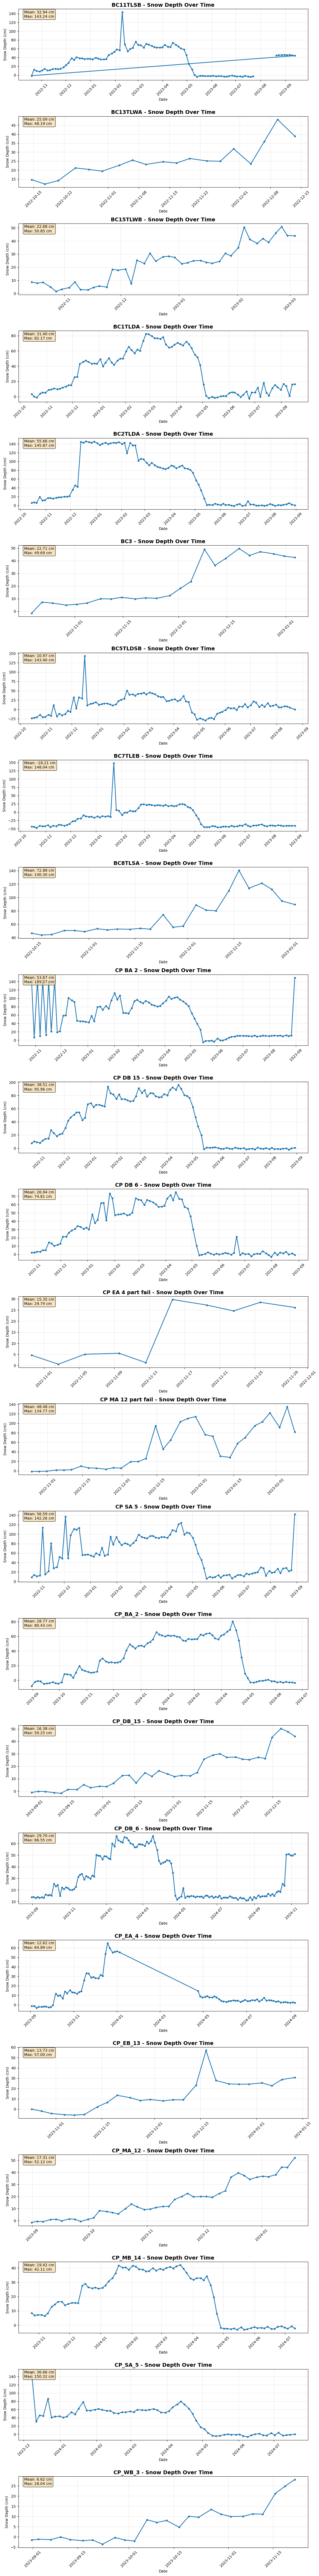

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Assuming your dataframe is called 'df'
# First, convert datetime column to proper datetime format
labels['datetime'] = pd.to_datetime(labels['datetime'])

# Get unique cameras
cameras = labels['camera_name'].unique()
print(f"Found {len(cameras)} cameras: {cameras}")

# Create subplots for each camera
fig, axes = plt.subplots(len(cameras), 1, figsize=(12, 4*len(cameras)))

# If only one camera, make axes a list for consistency
if len(cameras) == 1:
    axes = [axes]

# Plot each camera
for i, camera in enumerate(cameras):
    camera_data = labels[labels['camera_name'] == camera]
    
    # Plot snow depth over time
    axes[i].plot(camera_data['datetime'], camera_data['snow_depth_cm2'], 
                marker='o', linewidth=2, markersize=4, label='Snow Depth')
    
    axes[i].set_title(f'{camera} - Snow Depth Over Time', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Snow Depth (cm)')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add some statistics as text
    mean_depth = camera_data['snow_depth_cm2'].mean()
    max_depth = camera_data['snow_depth_cm2'].max()
    axes[i].text(0.02, 0.98, f'Mean: {mean_depth:.2f} cm\nMax: {max_depth:.2f} cm', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

Found 24 cameras: ['BC11TLSB' 'BC13TLWA' 'BC15TLWB' 'BC1TLDA' 'BC2TLDA' 'BC3' 'BC5TLDSB'
 'BC7TLEB' 'BC8TLSA' 'CP BA 2' 'CP DB 15' 'CP DB 6' 'CP EA 4 part fail'
 'CP MA 12 part fail' 'CP SA 5' 'CP_BA_2' 'CP_DB_15' 'CP_DB_6' 'CP_EA_4'
 'CP_EB_13' 'CP_MA_12' 'CP_MB_14' 'CP_SA_5' 'CP_WB_3']


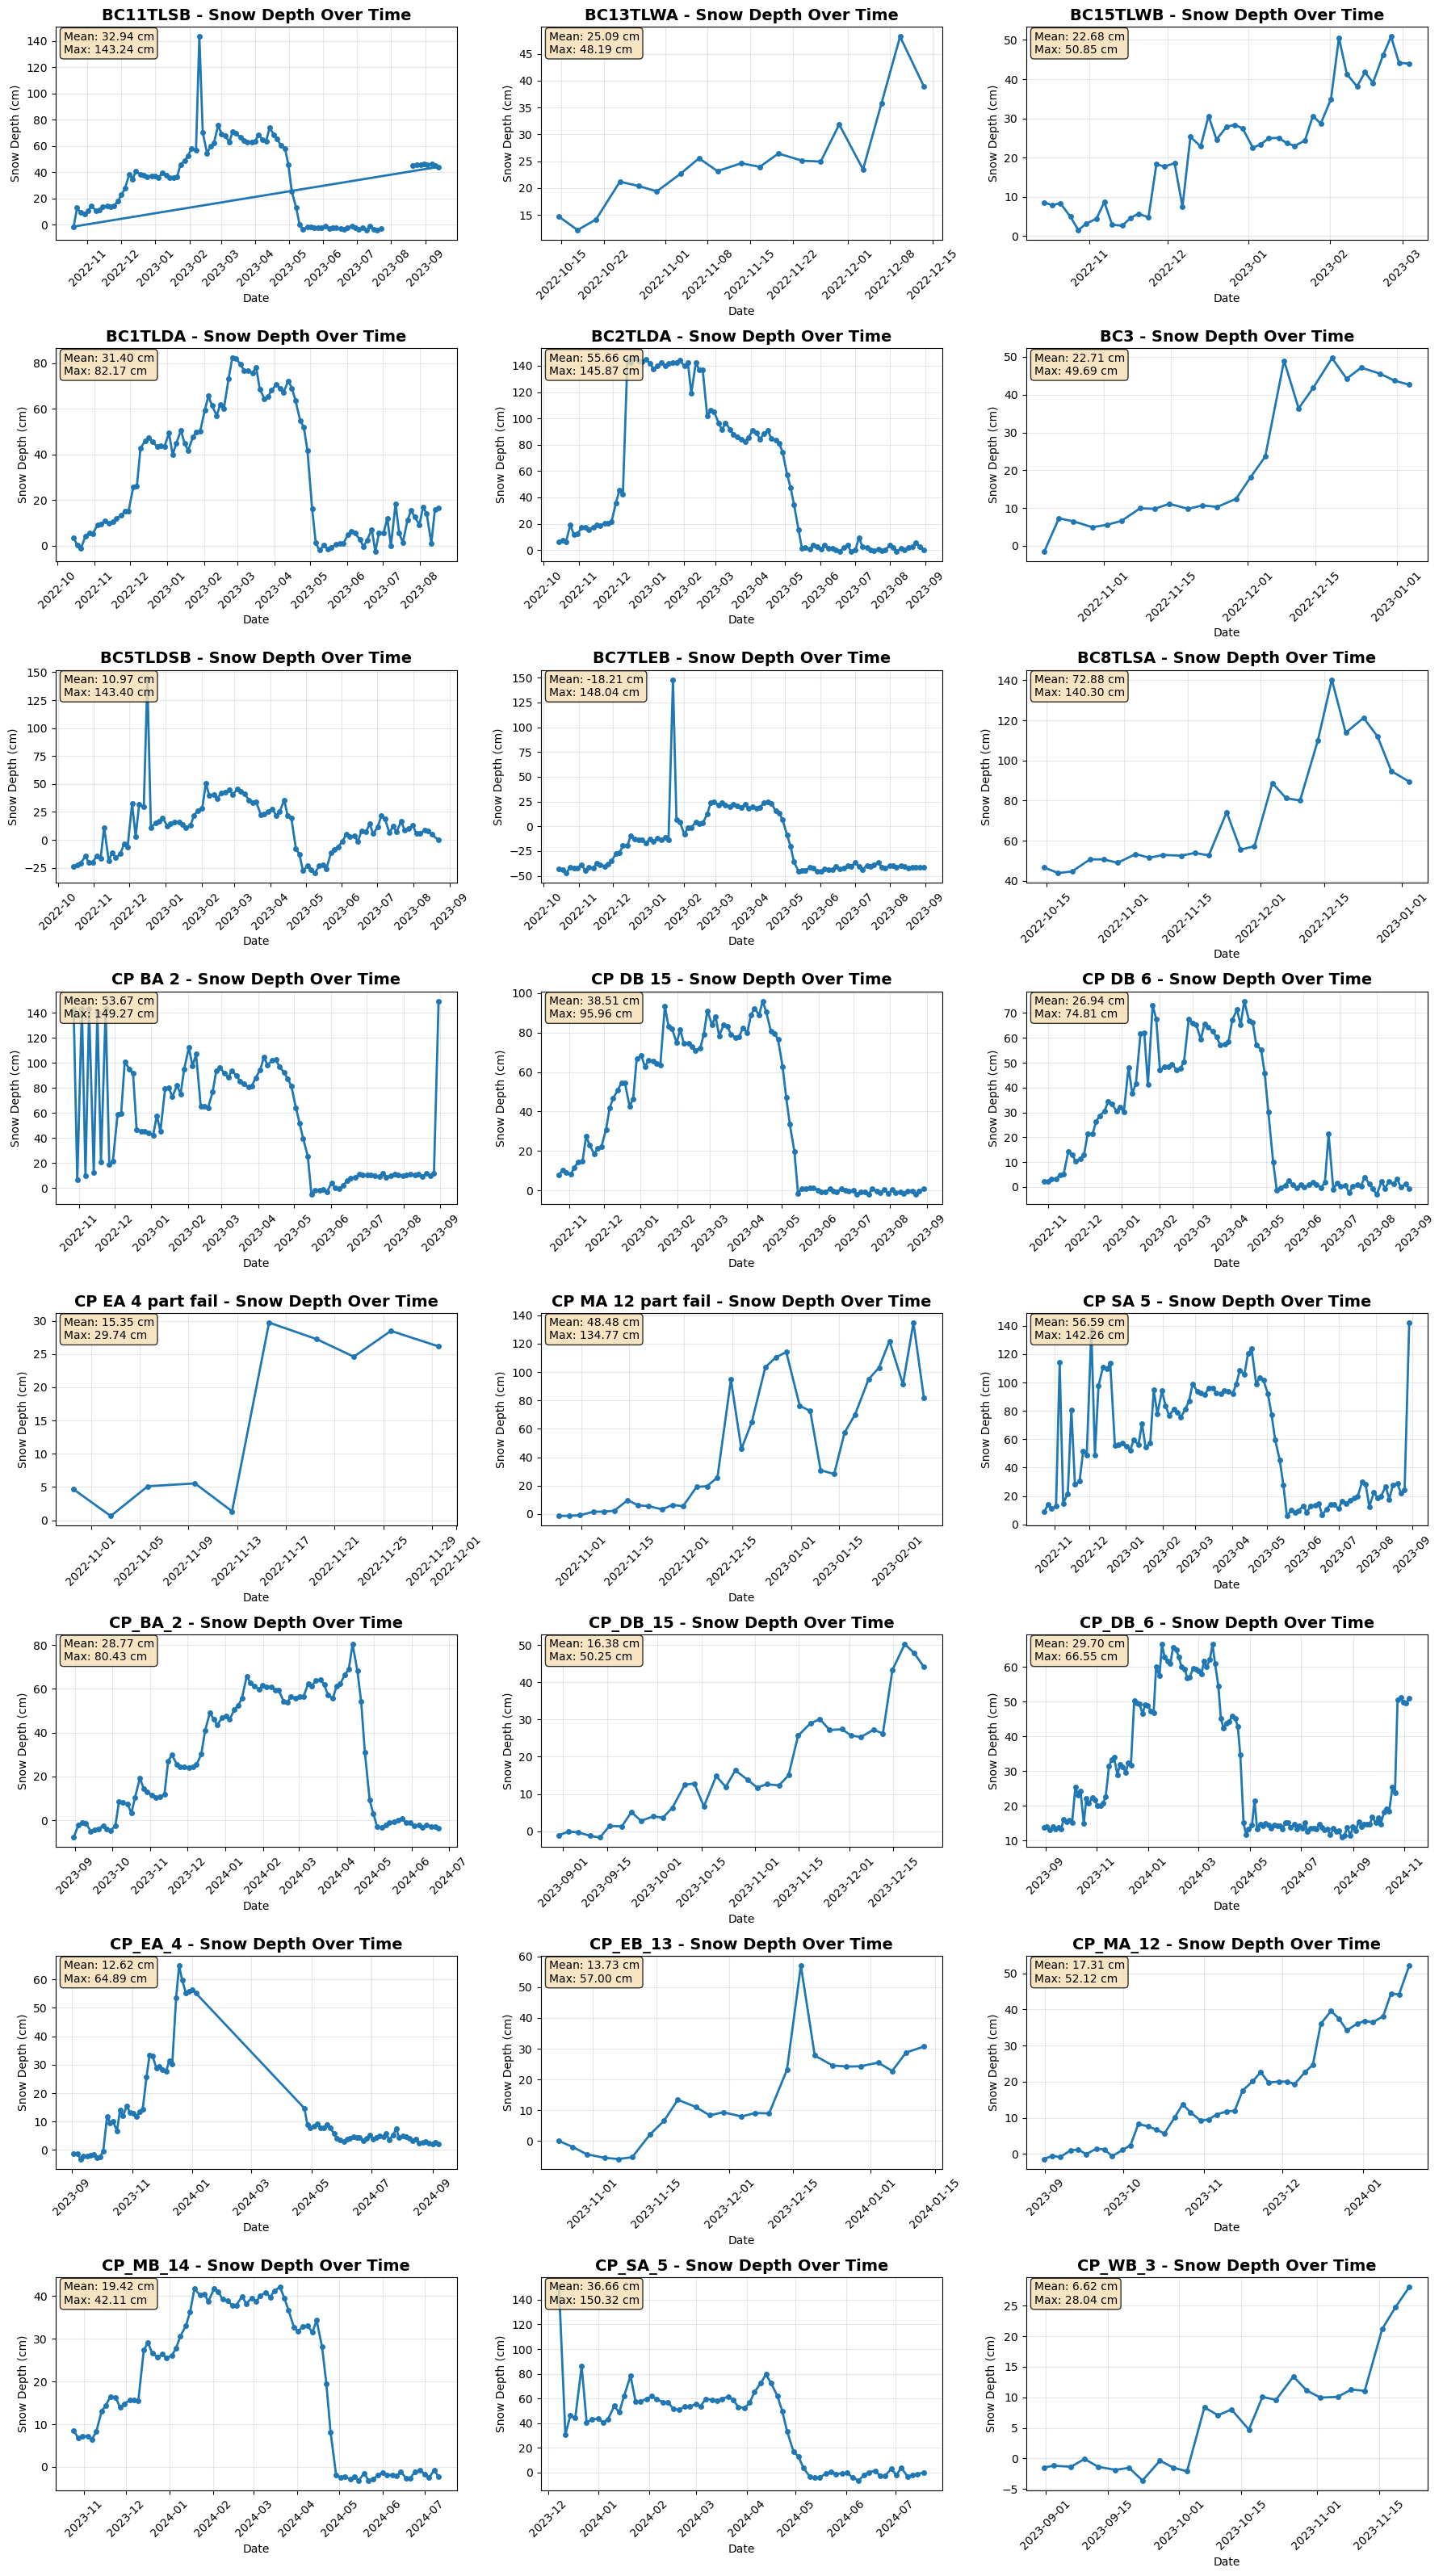

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import math

# Assuming your dataframe is called 'labels'
# First, convert datetime column to proper datetime format
labels['datetime'] = pd.to_datetime(labels['datetime'])

# Get unique cameras
cameras = labels['camera_name'].unique()
num_cameras = len(cameras)
print(f"Found {num_cameras} cameras: {cameras}")

# Calculate number of rows needed (3 columns)
num_cols = 3
num_rows = math.ceil(num_cameras / num_cols)

# Create subplots for each camera in a grid layout with 3 columns
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4*num_rows))

# Convert axes to a flattened array for easy indexing
axes = axes.flatten() if num_cameras > 1 else [axes]

# Plot each camera
for i, camera in enumerate(cameras):
    camera_data = labels[labels['camera_name'] == camera]
    
    # Plot snow depth over time
    axes[i].plot(camera_data['datetime'], camera_data['snow_depth_cm2'], 
                marker='o', linewidth=2, markersize=4, label='Snow Depth')
    
    axes[i].set_title(f'{camera} - Snow Depth Over Time', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Snow Depth (cm)')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add some statistics as text
    mean_depth = camera_data['snow_depth_cm2'].mean()
    max_depth = camera_data['snow_depth_cm2'].max()
    axes[i].text(0.02, 0.98, f'Mean: {mean_depth:.2f} cm\nMax: {max_depth:.2f} cm', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Found 24 cameras: ['BC11TLSB' 'BC13TLWA' 'BC15TLWB' 'BC1TLDA' 'BC2TLDA' 'BC3' 'BC5TLDSB'
 'BC7TLEB' 'BC8TLSA' 'CP BA 2' 'CP DB 15' 'CP DB 6' 'CP EA 4 part fail'
 'CP MA 12 part fail' 'CP SA 5' 'CP_BA_2' 'CP_DB_15' 'CP_DB_6' 'CP_EA_4'
 'CP_EB_13' 'CP_MA_12' 'CP_MB_14' 'CP_SA_5' 'CP_WB_3']


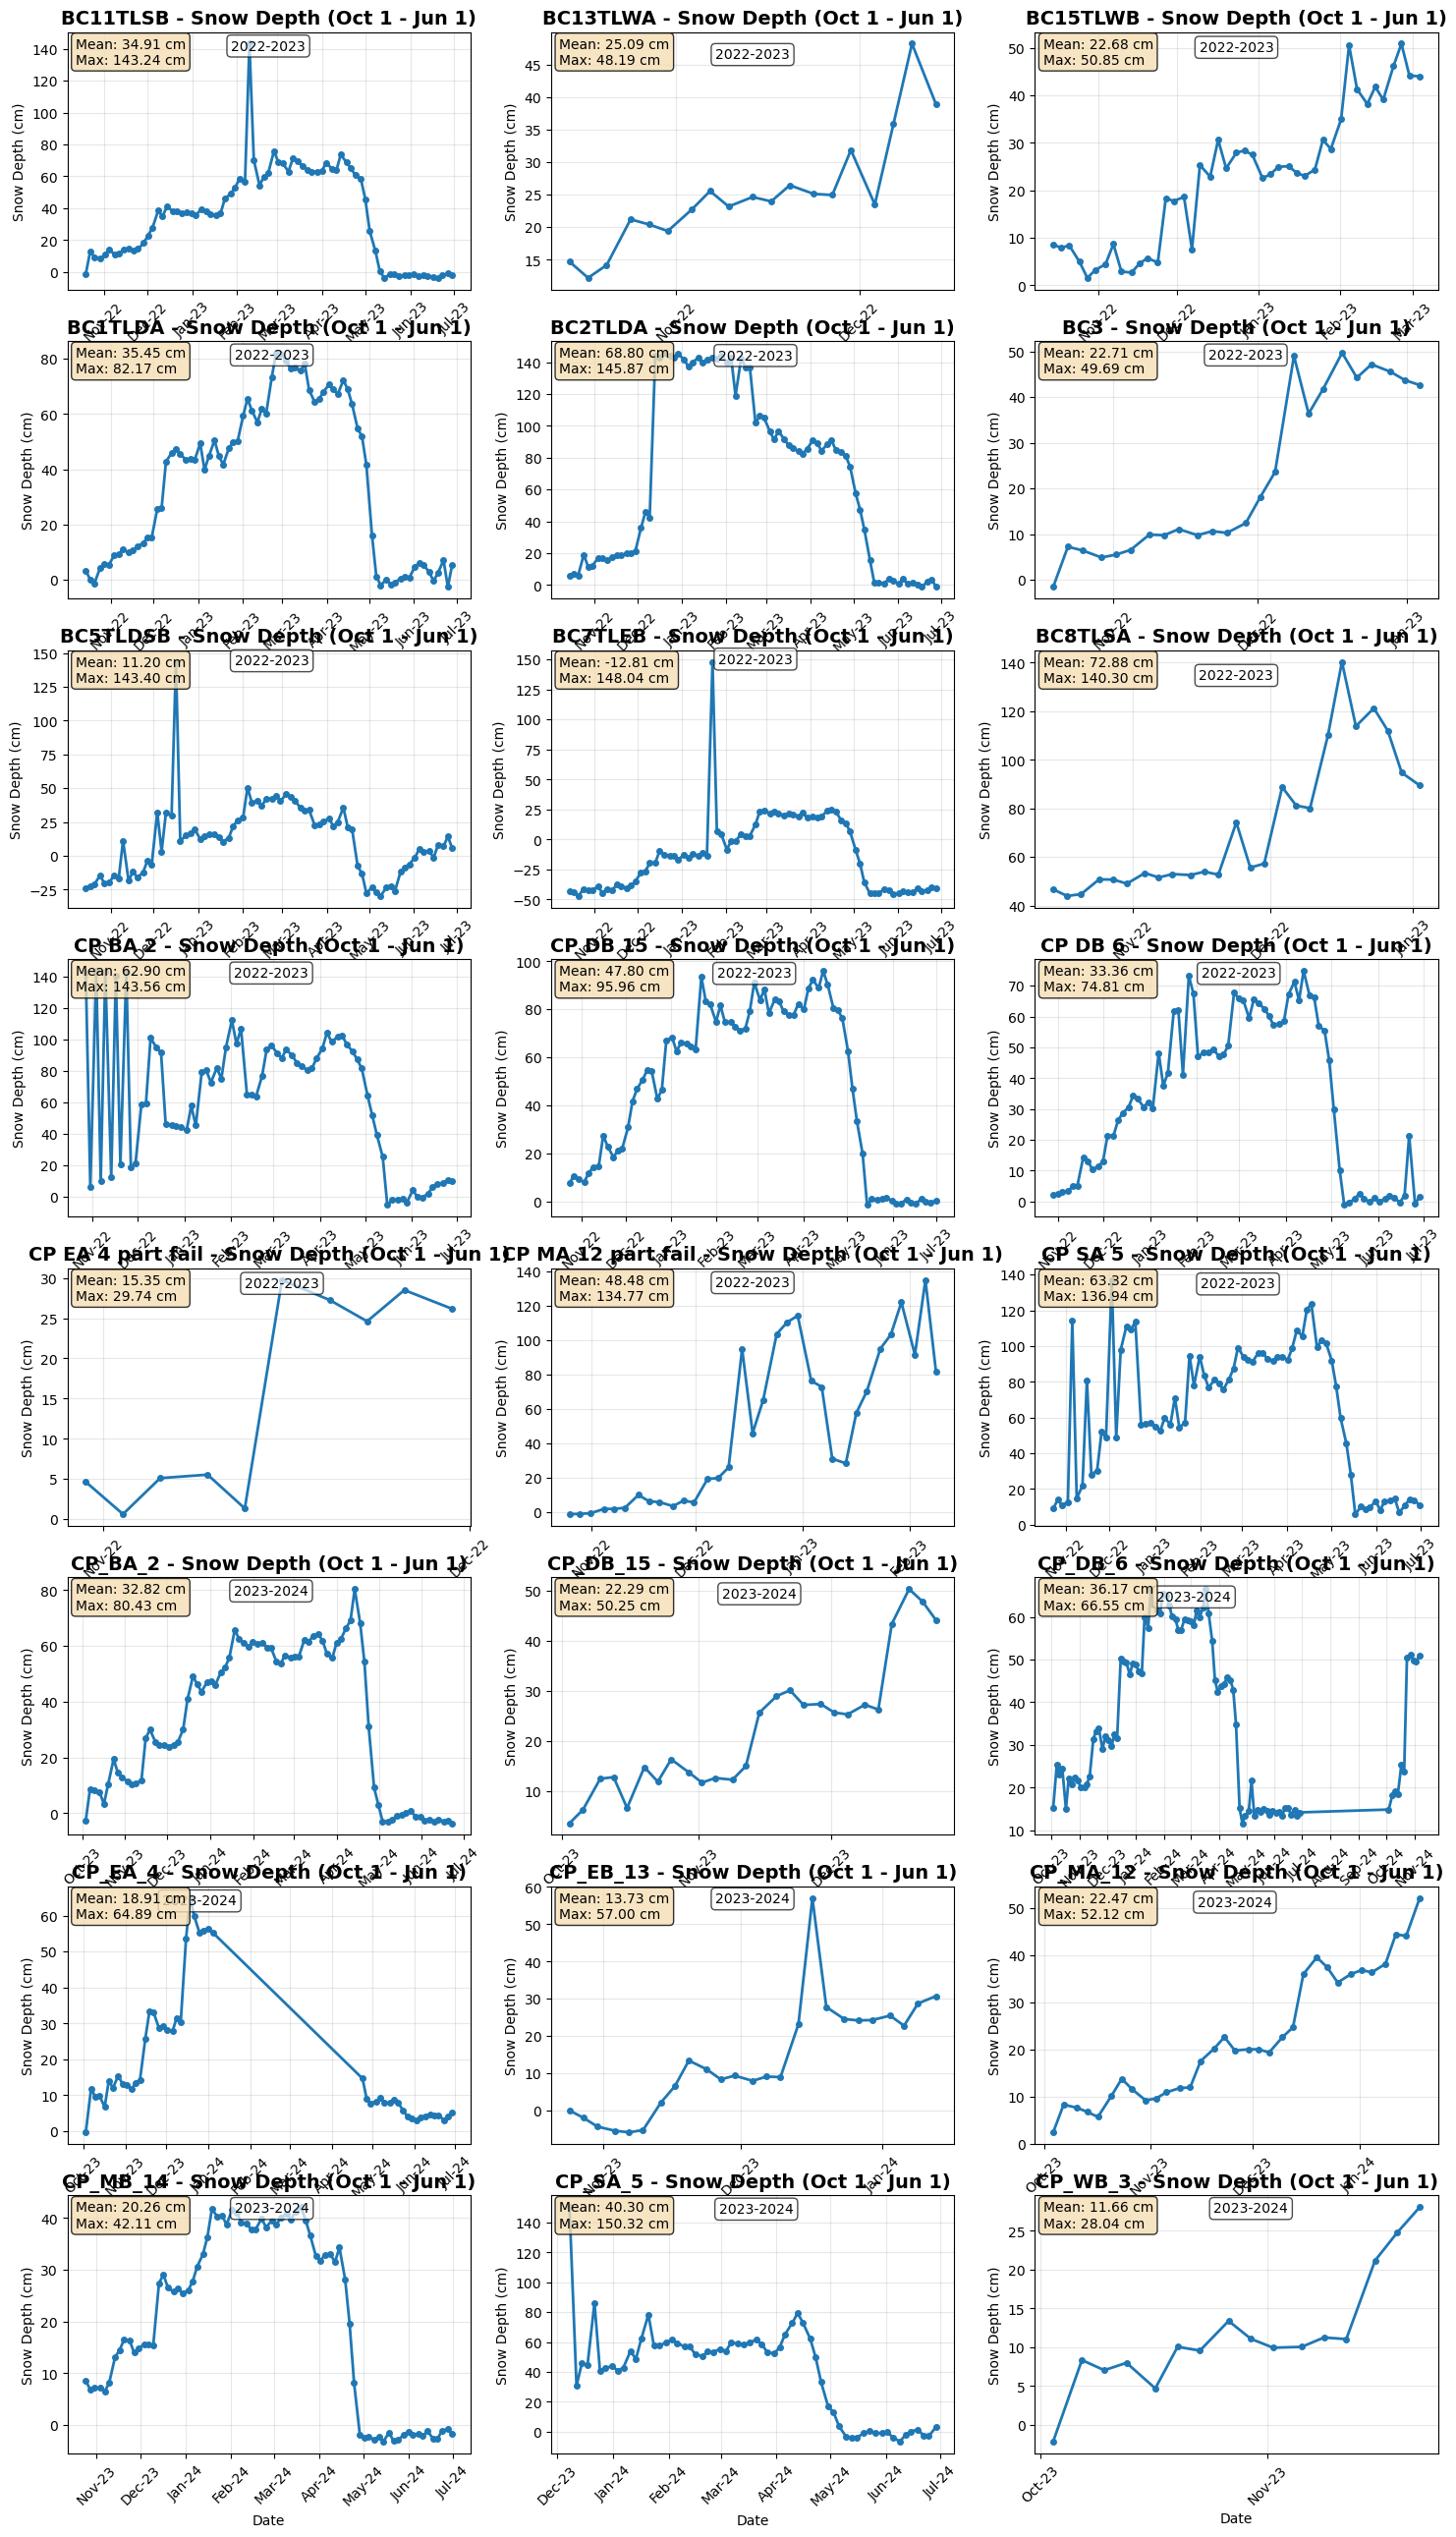

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import math

# Assuming your dataframe is called 'labels'
# First, convert datetime column to proper datetime format
labels['datetime'] = pd.to_datetime(labels['datetime'])

# Filter dates between October 1 and June 1 for any year
def is_in_snow_season(date):
    month = date.month
    return month >= 10 or month <= 6

# Apply filter to only include dates from Oct 1 to June 1
filtered_labels = labels[labels['datetime'].apply(is_in_snow_season)]

# Get unique cameras
cameras = filtered_labels['camera_name'].unique()
num_cameras = len(cameras)
print(f"Found {num_cameras} cameras: {cameras}")

# Calculate number of rows needed (3 columns)
num_cols = 3
num_rows = math.ceil(num_cameras / num_cols)

# Create subplots for each camera in a grid layout with 3 columns
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4*num_rows))

# Convert axes to a flattened array for easy indexing
axes = axes.flatten() if num_cameras > 1 else [axes]

# Plot each camera
for i, camera in enumerate(cameras):
    camera_data = filtered_labels[filtered_labels['camera_name'] == camera]
    
    # Skip if no data for this camera in the filtered period
    if len(camera_data) == 0:
        axes[i].text(0.5, 0.5, f"No data for {camera}\nin Oct 1 - Jun 1 period",
                    ha='center', va='center', fontsize=12)
        axes[i].set_title(f'{camera} - No Data', fontsize=14, fontweight='bold')
        axes[i].axis('off')
        continue
    
    # Plot snow depth over time
    axes[i].plot(camera_data['datetime'], camera_data['snow_depth_cm2'], 
                marker='o', linewidth=2, markersize=4, label='Snow Depth')
    
    # Add year annotations to separate seasons
    years = camera_data['year'].unique()
    for year in years:
        year_data = camera_data[camera_data['year'] == year]
        mid_point = year_data['datetime'].iloc[len(year_data)//2]
        axes[i].annotate(year, xy=(mid_point, camera_data['snow_depth_cm2'].max()*0.9),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', va='bottom', fontsize=10, 
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    axes[i].set_title(f'{camera} - Snow Depth (Oct 1 - Jun 1)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Snow Depth (cm)')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Format x-axis to show month and year
    from matplotlib.dates import MonthLocator, DateFormatter
    axes[i].xaxis.set_major_locator(MonthLocator())
    axes[i].xaxis.set_major_formatter(DateFormatter('%b-%y'))
    
    # Add some statistics as text
    mean_depth = camera_data['snow_depth_cm2'].mean()
    max_depth = camera_data['snow_depth_cm2'].max()
    axes[i].text(0.02, 0.98, f'Mean: {mean_depth:.2f} cm\nMax: {max_depth:.2f} cm', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')